 # **INTRODUCTION**
> In this competition your task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly. To help you make these predictions, you're given a set of personal records recovered from the ship's damaged computer system.
*In this notebook I have used various supervised learning methods to predict which passengers are transported to another world.*

# **IMPORTING DATA**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
space_train=pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
space_test=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
sample=pd.read_csv("/kaggle/input/spaceship-titanic/sample_submission.csv")

# **DATA EXPLORATION**

In [3]:
space_train.shape

(8693, 14)

In [4]:
space_test.shape

(4277, 13)

In [5]:
space_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
space_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [7]:
space_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
space_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [9]:
space_train.PassengerId.nunique()/space_train.shape[0]

1.0

In [10]:
space_train.Transported.value_counts()

True     4378
False    4315
Name: Transported, dtype: int64

In [11]:
space_train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [12]:
null_value=space_test.isnull().sum()
null_value

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [13]:
# Replacing the null values 
space_train["HomePlanet"].fillna(method="ffill",inplace=True)
space_train["CryoSleep"].fillna(method="ffill",inplace=True)
space_train["Cabin"].fillna(method="ffill",inplace=True)
space_train["Destination"].fillna(method="ffill",inplace=True)
space_train["Age"].fillna(space_train["Age"].mean(),inplace=True)
space_train["VIP"].fillna(method="ffill",inplace=True)
space_train["RoomService"].fillna(space_train["RoomService"].mean(),inplace=True)
space_train["FoodCourt"].fillna(space_train["FoodCourt"].mean(),inplace=True)
space_train["ShoppingMall"].fillna(space_train["ShoppingMall"].mean(),inplace=True)
space_train["Spa"].fillna(space_train["Spa"].mean(),inplace=True)
space_train["VRDeck"].fillna(space_train["VRDeck"].mean(),inplace=True)
space_train["Name"].fillna(method="ffill",inplace=True)


In [14]:
# Rechecking after eliminating null values
space_train.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [15]:
# Replacing the null values 
space_test["HomePlanet"].fillna(method="ffill",inplace=True)
space_test["CryoSleep"].fillna(method="ffill",inplace=True)
space_test["Cabin"].fillna(method="ffill",inplace=True)
space_test["Destination"].fillna(method="ffill",inplace=True)
space_test["Age"].fillna(space_test["Age"].mean(),inplace=True)
space_test["VIP"].fillna(method="ffill",inplace=True)
space_test["RoomService"].fillna(space_test["RoomService"].mean(),inplace=True)
space_test["FoodCourt"].fillna(space_test["FoodCourt"].mean(),inplace=True)
space_test["ShoppingMall"].fillna(space_test["ShoppingMall"].mean(),inplace=True)
space_test["Spa"].fillna(space_test["Spa"].mean(),inplace=True)
space_test["VRDeck"].fillna(space_test["VRDeck"].mean(),inplace=True)
space_test["Name"].fillna(method="ffill",inplace=True)

In [16]:
# Rechecking after eliminating null values
space_test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

<AxesSubplot:>

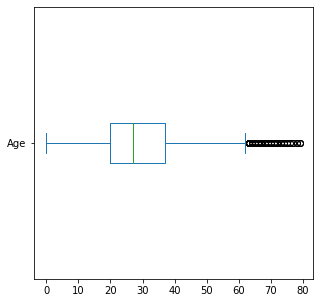

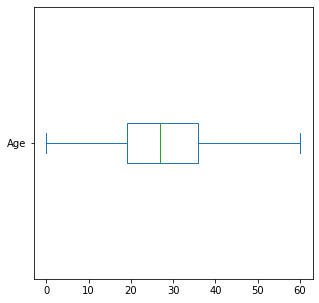

In [17]:
plt.figure(figsize=(5, 5))
space_train["Age"].plot.box(vert=False)
space_train=space_train[(space_train["Age"]<=60)]
plt.figure(figsize=(5, 5))
space_train["Age"].plot.box(vert=False)

,FoodCourt,ShoppingMall,Spa,VRDeck,RoomService
0.95,2640.20,910.00,1529.00,1480.20,1252.80
0.96,3343.12,1083.12,1867.12,1854.56,1445.36
0.97,4019.68,1348.84,2570.84,2371.36,1751.84
0.98,5171.56,1725.04,3636.28,3625.84,2190.12
0.99,7993.12,2319.92,5255.60,5577.56,3036.28
1.00,29813.00,23492.00,18572.00,24133.00,14327.00


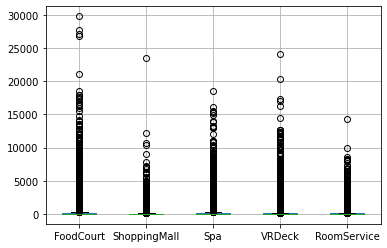

In [18]:
expenses=["FoodCourt","ShoppingMall","Spa","VRDeck","RoomService"]
space_train.boxplot(column=expenses)
q_value =[i/100 for i in range (95,101,1)]
q1=space_train[expenses].quantile(q_value)
q1


(8075, 14)


<AxesSubplot:>

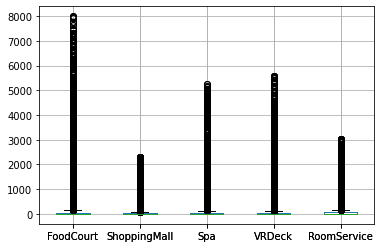

In [19]:
space_train=space_train[(space_train["FoodCourt"]<=7993.12) & (space_train["ShoppingMall"]<=2319.92)& (space_train["Spa"]<=5255.60)& (space_train["VRDeck"]<=5577.56)& (space_train["RoomService"]<=3036.28)]
space_train.shape
space_train.boxplot(column=expenses)
space_train=space_train[(space_train["FoodCourt"]<=7993.12) & (space_train["ShoppingMall"]<=2319.92)& (space_train["Spa"]<=5255.60)& (space_train["VRDeck"]<=5577.56)& (space_train["RoomService"]<=3036.28)]
print(space_train.shape)
space_train.boxplot(column=expenses)

# **DATA VISUALIZATION**

<AxesSubplot:title={'center':'Distribution of Transported Passengers'}, ylabel='Transported'>

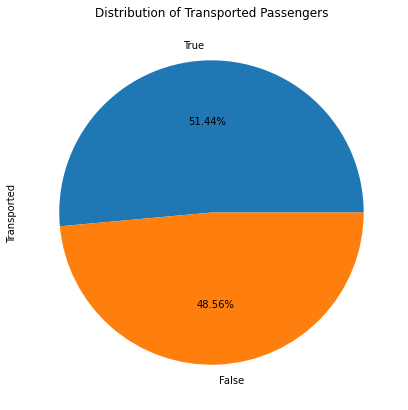

In [20]:
plt.figure(figsize=(7,7))
plt.title("Distribution of Transported Passengers")
space_train["Transported"].value_counts().plot(kind="pie",autopct='%1.2f%%')

There is not much difference in the distribution of Transported and non transported passengers. Hence, the data is unbaised. 

Text(0.5, 1.0, 'Transported successfully from Home Planet')

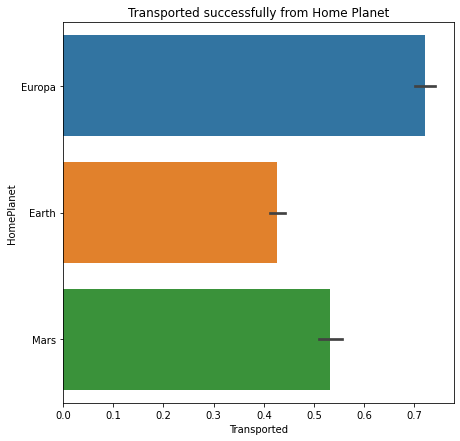

In [21]:
plt.figure(figsize=(7,7))
sns.barplot(x="Transported",y="HomePlanet",data=space_train)
plt.title("Transported successfully from Home Planet")

Maximum no of passengers transported are from planet Eupora

<AxesSubplot:title={'center':' Passengers Confined to Cabins'}, ylabel='CryoSleep'>

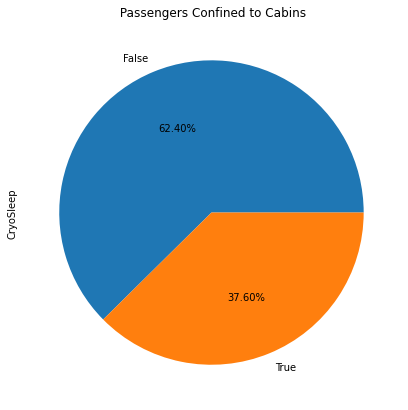

In [22]:
plt.figure(figsize=(7,7))
plt.title(" Passengers Confined to Cabins")
space_train["CryoSleep"].value_counts().plot(kind="pie",autopct='%1.2f%%')

Text(0.5, 1.0, 'Confined Passengers Transported')

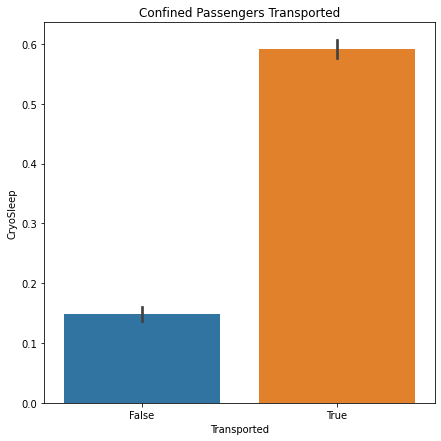

In [23]:
plt.figure(figsize=(7,7))
sns.barplot(x="Transported",y="CryoSleep",data=space_train)
plt.title("Confined Passengers Transported")

Maximum confined passengers are transported.

<AxesSubplot:ylabel='Destination'>

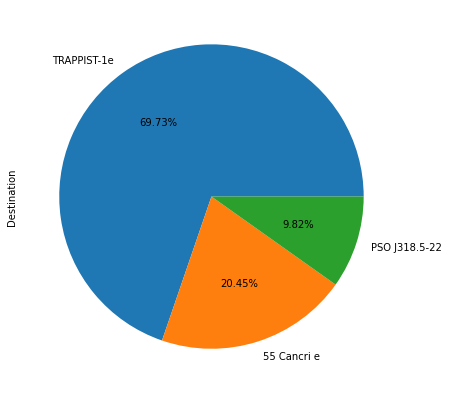

In [24]:
plt.figure(figsize=(7,7))
space_train["Destination"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<AxesSubplot:xlabel='Transported', ylabel='Destination'>

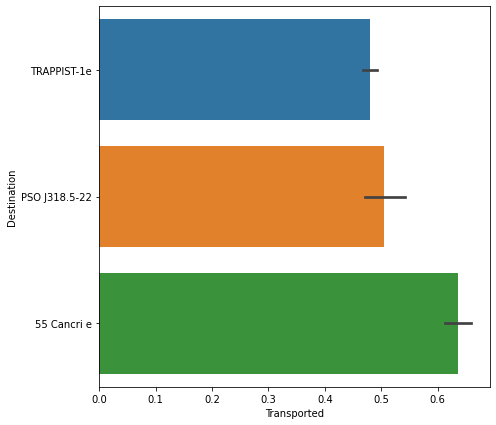

In [25]:
plt.figure(figsize=(7,7))
sns.barplot(x="Transported",y="Destination",data=space_train)

Maximum transported to 55 Cancri e

<AxesSubplot:ylabel='Side'>

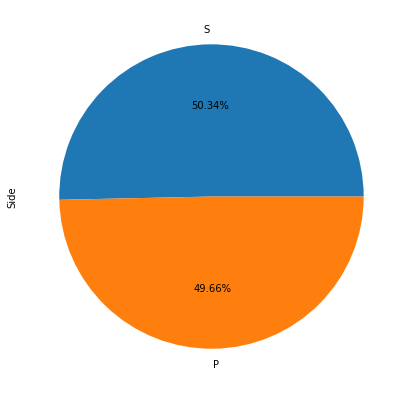

In [26]:
# splitting the cabin to Side : Port(P)  or Standard(S)
space_train["Side"]=space_train["Cabin"].str.split("/").str[2] 
space_test["Side"]=space_test["Cabin"].str.split("/").str[2] 
plt.figure(figsize=(7,7))
space_train["Side"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<Figure size 504x504 with 0 Axes>

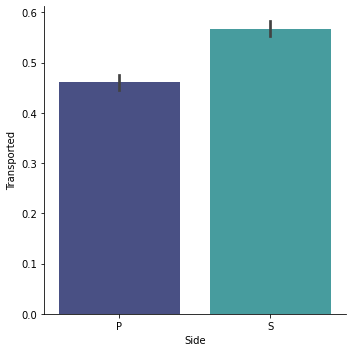

In [27]:
plt.figure(figsize=(7,7))
sns.catplot(x="Side",y="Transported",kind="bar",palette="mako",data=space_train)

<AxesSubplot:ylabel='Deck'>

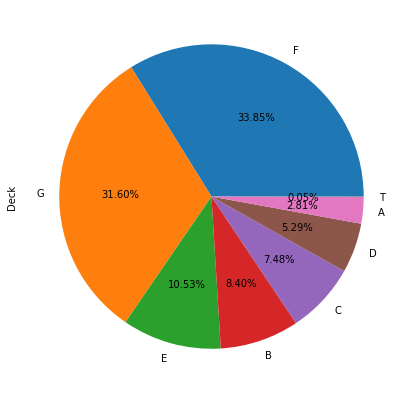

In [28]:
space_train["Deck"]=space_train["Cabin"].str.split("/").str[0] 
space_test["Deck"]=space_test["Cabin"].str.split("/").str[0] 
plt.figure(figsize=(7,7))
space_train["Deck"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<Figure size 504x504 with 0 Axes>

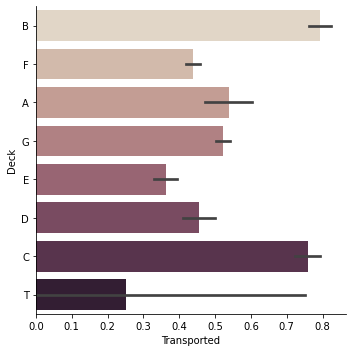

In [29]:
plt.figure(figsize=(7,7))
sns.catplot(x="Transported",y="Deck",kind="bar",palette="ch:.25",data=space_train)

<Figure size 720x720 with 0 Axes>

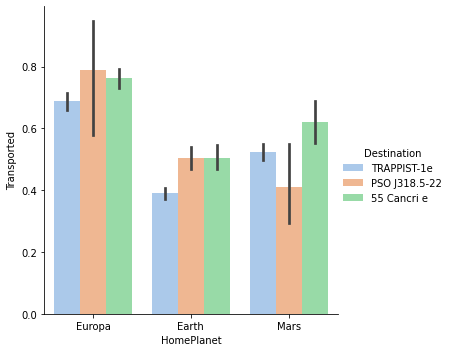

In [30]:
plt.figure(figsize=(10,10))
sns.catplot(x="HomePlanet",y="Transported",hue="Destination",kind="bar",palette="pastel",data=space_train)

<Figure size 720x720 with 0 Axes>

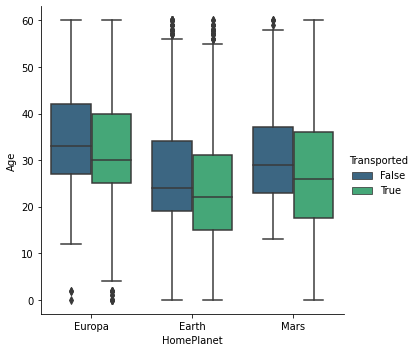

In [31]:
plt.figure(figsize=(10,10))
sns.catplot(x="HomePlanet",y="Age",hue="Transported",kind="box",palette="viridis",data=space_train)

<AxesSubplot:ylabel='VIP'>

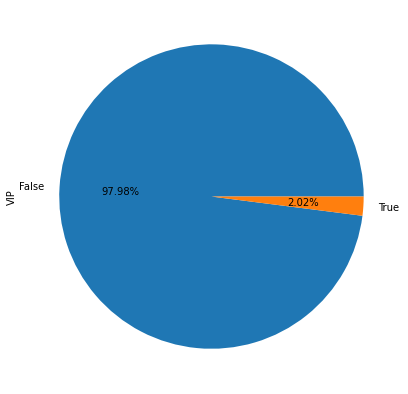

In [32]:
plt.figure(figsize=(7,7))
space_train["VIP"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<Figure size 720x720 with 0 Axes>

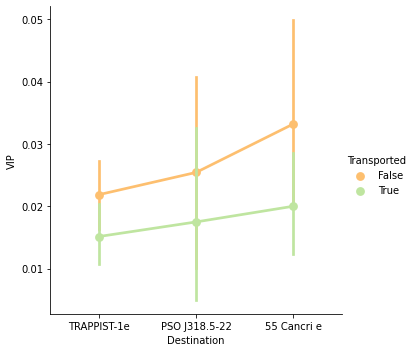

In [33]:
plt.figure(figsize=(10,10))
sns.catplot(x="Destination",y="VIP",hue="Transported",kind="point",palette="Spectral",data=space_train)

<Figure size 720x720 with 0 Axes>

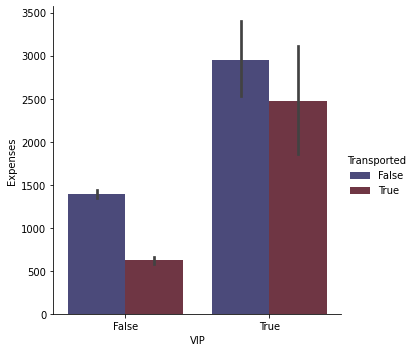

In [34]:
space_train["Expenses"]=space_train["RoomService"]+space_train["FoodCourt"]+space_train["ShoppingMall"]+space_train["Spa"]+space_train["VRDeck"]
plt.figure(figsize=(10,10))
sns.catplot(x="VIP",y="Expenses",hue="Transported",kind="bar",palette="icefire",data=space_train)

<Figure size 720x720 with 0 Axes>

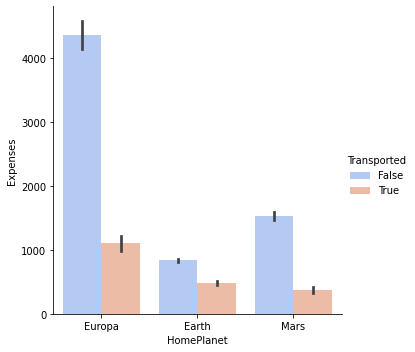

In [35]:
plt.figure(figsize=(10,10))
sns.catplot(x="HomePlanet",y="Expenses",hue="Transported",kind="bar",palette="coolwarm",data=space_train)

<AxesSubplot:xlabel='Age', ylabel='Expenses'>

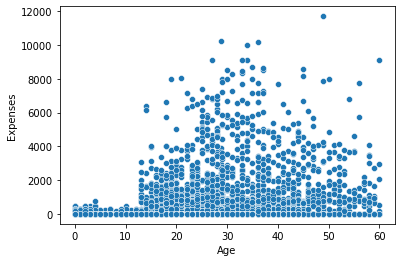

In [36]:
sns.scatterplot(x='Age',y='Expenses',data=space_train[space_train.Transported==True])

<AxesSubplot:xlabel='Side', ylabel='Expenses'>

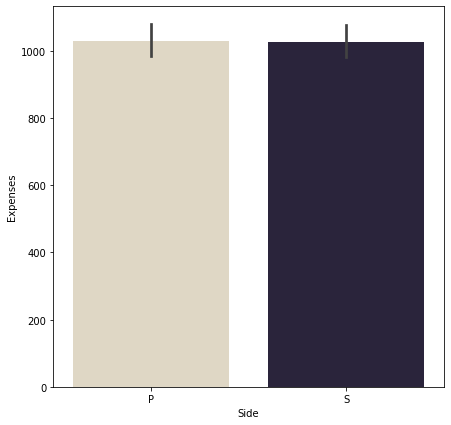

In [37]:
plt.figure(figsize=(7,7))
sns.barplot(x="Side",y="Expenses",palette="ch:s=-.2,r=.6",data=space_train)

# **DATA ENCODING**

In [38]:
space_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Side,Deck,Expenses
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,P,B,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,S,F,736.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,S,A,5176.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,S,F,1091.0
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,P,F,774.0


In [39]:
space_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Side,Deck
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,S,G
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,S,F
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,S,C
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,S,C
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,S,F


In [40]:
space_train.drop(["PassengerId","Name","Expenses","Cabin"],inplace=True,axis=1)
space_test.drop(["PassengerId","Name","Cabin"],inplace=True,axis=1)

In [41]:
space_train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Side,Deck
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,P,B
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,S,F
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,S,A
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,S,F
5,Earth,False,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,True,P,F


In [42]:
space_test.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Side,Deck
0,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,S,G
1,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,S,F
2,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,S,C
3,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,S,C
4,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,S,F


In [43]:
categorical_var=[i for i in space_train.columns if space_train[i].dtypes=='object']
for z in categorical_var:
    print(space_train[z].name,':',space_train[z].unique())

HomePlanet : ['Europa' 'Earth' 'Mars']
Destination : ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']
Side : ['P' 'S']
Deck : ['B' 'F' 'A' 'G' 'E' 'D' 'C' 'T']


      CryoSleep   Age    VIP  RoomService  FoodCourt  ShoppingMall     Spa  \
0         False  39.0  False          0.0        0.0           0.0     0.0   
1         False  24.0  False        109.0        9.0          25.0   549.0   
3         False  33.0  False          0.0     1283.0         371.0  3329.0   
4         False  16.0  False        303.0       70.0         151.0   565.0   
5         False  44.0  False          0.0      483.0           0.0   291.0   
...         ...   ...    ...          ...        ...           ...     ...   
8688      False  41.0   True          0.0     6819.0           0.0  1643.0   
8689       True  18.0  False          0.0        0.0           0.0     0.0   
8690      False  26.0  False          0.0        0.0        1872.0     1.0   
8691      False  32.0  False          0.0     1049.0           0.0   353.0   
8692      False  44.0  False        126.0     4688.0           0.0     0.0   

      VRDeck  Transported  
0        0.0        False  
1      

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>], dtype=object)

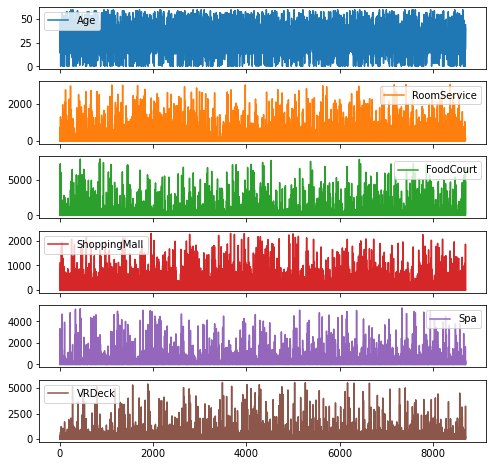

In [44]:
numerical_var=space_train[[i for i in space_train.columns if space_train[i].dtypes !='object']]
print(numerical_var)
numerical_var.plot(subplots=True, figsize=(8, 8))

In [45]:
categorical_var=[i for i in space_test.columns if space_test[i].dtypes=='object']
for z in categorical_var:
    print(space_test[z].name,':',space_test[z].unique())

HomePlanet : ['Earth' 'Europa' 'Mars']
Destination : ['TRAPPIST-1e' '55 Cancri e' 'PSO J318.5-22']
Side : ['S' 'P']
Deck : ['G' 'F' 'C' 'B' 'D' 'E' 'A' 'T']


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>], dtype=object)

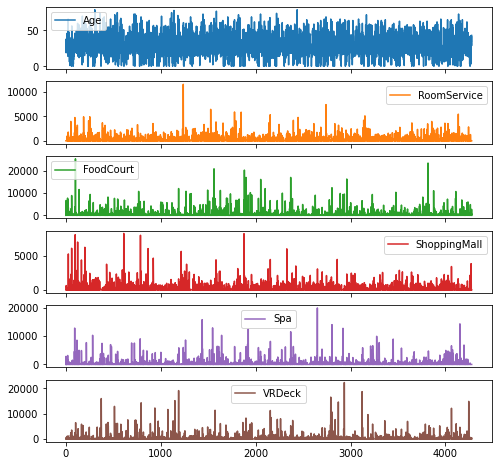

In [46]:
numerical_var=space_test[[i for i in space_test.columns if space_test[i].dtypes !='object']]
numerical_var
numerical_var.plot(subplots=True, figsize=(8, 8))

In [47]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
for x in [i for i in space_train.columns if len(space_train[i].unique())==2]:
    space_train[x]= label_encoder.fit_transform(space_train[x])
    

In [48]:
#Encode Variables with more than 2 Classes
space_train= pd.get_dummies(space_train, columns= [i for i in space_train.columns if space_train[i].dtypes=='object'],drop_first=True)


In [49]:
label_encoder=LabelEncoder()
for x in [i for i in space_test.columns if len(space_test[i].unique())==2]:
    space_test[x]= label_encoder.fit_transform(space_test[x])

In [50]:
#Encode Variables with more than 2 Classes
space_test= pd.get_dummies(space_test, columns= [i for i in space_test.columns if space_test[i].dtypes=='object'],drop_first=True)

In [51]:
space_train.shape

(8075, 21)

In [52]:
space_test.shape

(4277, 20)

# **SPLITTING DATA**

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report,accuracy_score
from sklearn.metrics import roc_curve , auc
from sklearn.preprocessing import StandardScaler

In [54]:
## Defining variables X,y 
x_train= space_train.drop(["Transported"],axis=1)
x_test=space_test
Y_train=space_train["Transported"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(x_train, Y_train, test_size = 0.25, random_state = 0)

In [56]:
print("shape of X_train:",X_train.shape)
print("shape of y_train:",y_train.shape[0])

shape of X_train: (6056, 20)
shape of y_train: 6056


In [57]:
space_train.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Side,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,0,...,0,0,1,1,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,1,...,0,0,1,0,0,0,0,1,0,0
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,1,...,0,0,1,0,0,0,0,1,0,0
5,0,44.0,0,0.0,483.0,0.0,291.0,0.0,1,0,...,0,1,0,0,0,0,0,1,0,0


In [58]:
## Scaling the data 
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test=sc.transform(X_test)
X_train=pd.DataFrame(X_train,columns=x_train.columns)
X_test=pd.DataFrame(X_test,columns=x_test.columns)

# **MODEL PREDICTION**

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

LR: 0.781701 (0.010394)
LDA: 0.775758 (0.010597)
KNN: 0.767337 (0.013183)
CART: 0.729523 (0.021489)
NB: 0.744887 (0.042871)
SVM: 0.789631 (0.009258)
RFC: 0.783684 (0.016629)


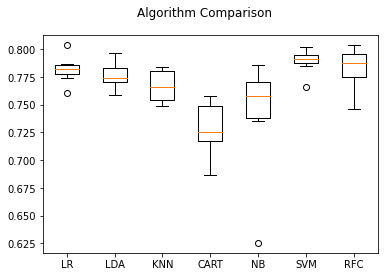

In [60]:
# prepare configuration for cross validation test harness
seed = 7
# prepare models
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('RFC',RandomForestClassifier(max_depth=20,random_state=200)))
models.append
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = model_selection.KFold(n_splits=10)
    cv_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

The RFC has highest accuracy rate.

# **MODEL SELECTION**


In [61]:
model=RandomForestClassifier(max_depth=100,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=100, random_state=42)

In [62]:
y_pred=model.predict(X_test)

In [63]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       976
           1       0.82      0.75      0.78      1043

    accuracy                           0.78      2019
   macro avg       0.79      0.79      0.78      2019
weighted avg       0.79      0.78      0.78      2019



Confusion matrix is 
 [[800 176]
 [259 784]]


Text(42.0, 0.5, 'predicted label')

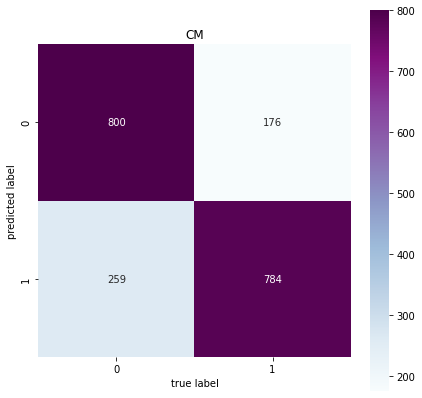

In [64]:
## confusion matrix
conf_mat=confusion_matrix(y_test,y_pred)
print("Confusion matrix is \n",conf_mat)

## plotting confusion matrix
plt.figure(figsize=(7,7))
plt.title("CM")
sns.heatmap(conf_mat, square=True,cmap="BuPu",annot=True,fmt='d')
plt.xlabel('true label')
plt.ylabel('predicted label')

In [65]:
y_pred_proba = model.predict_proba(X_test)[:,1]

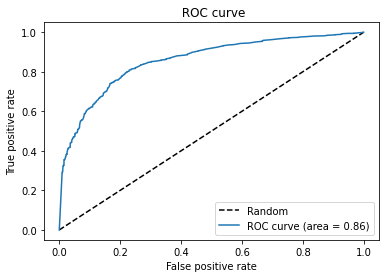

In [66]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc=auc(fpr,tpr)
#Now Draw ROC using fpr , tpr
plt.plot([0, 1], [0, 1], 'k--',label='Random')
plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)' %roc_auc)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title(" ROC curve")
plt.legend(loc='best')

<AxesSubplot:title={'center':'Distribution of Transported Passengers'}, ylabel='Transported'>

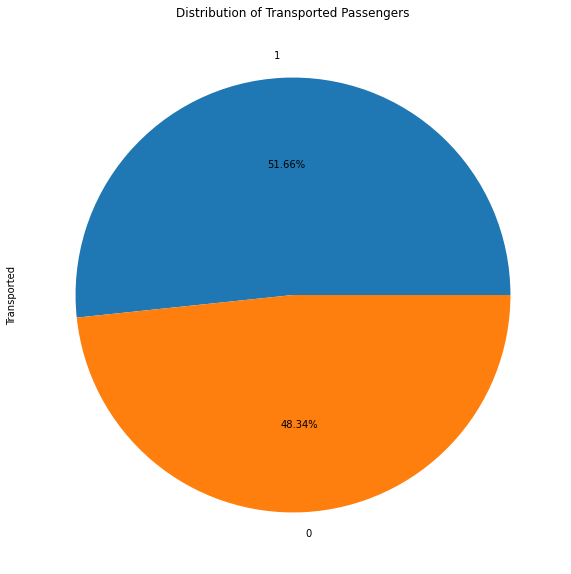

In [67]:
## Distribution of Transported Passengers
plt.figure(figsize=(10,10))
plt.title("Distribution of Transported Passengers")
y_test.value_counts().plot(kind="pie",autopct='%1.2f%%')

# **SMOTE**

In [68]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
smote_X,smote_y=smote.fit_resample(X_train,y_train)

<AxesSubplot:title={'center':'Distribution of Transported Passengers'}, ylabel='Transported'>

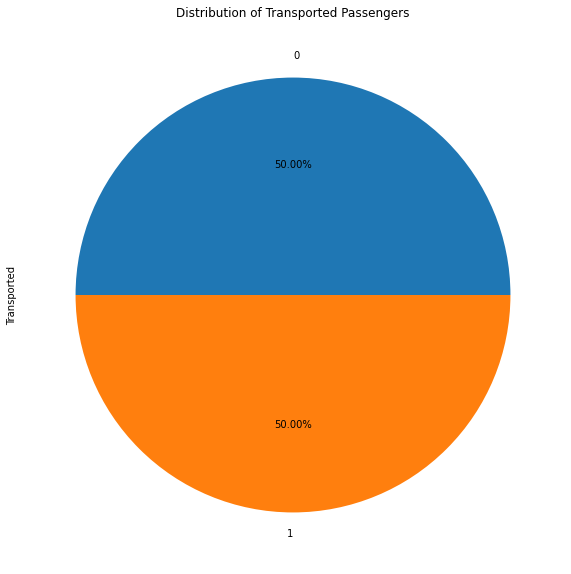

In [69]:
## Distribution of heart diseases
plt.figure(figsize=(10,10))
plt.title("Distribution of Transported Passengers")
smote_y.value_counts().plot(kind="pie",autopct='%1.2f%%')

In [70]:
model_smote=RandomForestClassifier(max_depth=100,random_state=42)
model_smote.fit(smote_X,smote_y)

RandomForestClassifier(max_depth=100, random_state=42)

In [71]:
y_pred_smote=model_smote.predict(X_test)

In [72]:
## classification report
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

           0       0.75      0.82      0.79       976
           1       0.82      0.75      0.78      1043

    accuracy                           0.78      2019
   macro avg       0.79      0.79      0.78      2019
weighted avg       0.79      0.78      0.78      2019



Confusion matrix is 
 [[805 171]
 [265 778]]


Text(42.0, 0.5, 'Actual value')

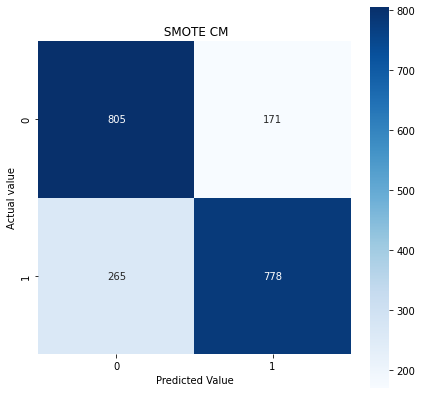

In [73]:
## confusion matrix
conf_mat_smote=confusion_matrix(y_test,y_pred_smote)
print("Confusion matrix is \n",conf_mat_smote)

## plotting confusion matrix

plt.figure(figsize=(7,7))
plt.title(" SMOTE CM")
sns.heatmap(conf_mat_smote, square=True,cmap="Blues",annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual value")

In [74]:
print("accuracy:", round(100*accuracy_score(y_test,y_pred_smote)),"%")

accuracy: 78 %


In [75]:
y_pred_proba_smote = model_smote.predict_proba(X_test)[:,1]

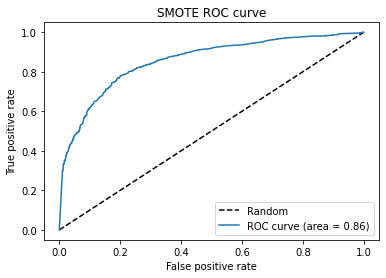

In [76]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_smote)
roc_auc=auc(fpr,tpr)
#Now Draw ROC using fpr , tpr
plt.plot([0, 1], [0, 1], 'k--',label='Random')
plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)' %roc_auc)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('SMOTE ROC curve')
plt.legend(loc='best')

# **FEATURES**

<AxesSubplot:title={'center':'Feature importance plot'}>

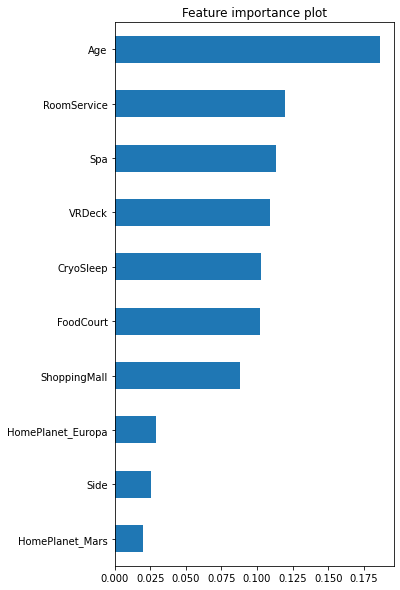

In [77]:
xx= pd.Series(model.feature_importances_,index=x_train.columns)
plt.figure(figsize =(5,10))
plt.title("Feature importance plot")
xx.nlargest(10).sort_values(ascending=True).plot(kind="barh",)


In [78]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
fit = pca.fit(x_train)
# summarize components
print("Explained Variance: %s" % fit.explained_variance_ratio_)
print(fit.components_)

Explained Variance: [0.48656588 0.19451043 0.15968745]
[[-1.47131603e-04  2.29995589e-03  2.02339059e-05 -2.77215549e-02
   9.42754249e-01 -1.48736834e-02  2.25101549e-01  2.44025893e-01
   6.38966812e-06  1.82341382e-04 -6.75031903e-05 -2.23540684e-05
  -1.56069249e-05  4.41256352e-05  7.84571550e-05  1.30695964e-05
  -1.12941104e-05 -6.25657847e-05 -8.97625006e-05  9.04718411e-07]
 [-1.59297386e-04  1.61476118e-03  1.04381819e-05 -2.09156078e-02
  -3.32294578e-01 -2.35479170e-02  6.81282251e-01  6.51490745e-01
  -8.53737160e-06  9.07508065e-05 -4.89098872e-05 -1.36903436e-05
  -7.57239581e-06  1.24768925e-05  2.96112281e-05  1.10477396e-05
   5.60224297e-06 -4.94197708e-06 -7.09883848e-05  5.77506752e-07]
 [ 3.72637763e-06 -1.19357443e-04  4.83737526e-06  4.77240033e-03
  -1.95543751e-02 -4.53795740e-03 -6.95951717e-01  7.17792066e-01
  -1.47783434e-05  1.62231849e-05 -2.63767658e-05  4.94779476e-06
  -1.14568534e-05  9.39341339e-06  7.48641667e-06 -1.00954619e-05
  -4.21125565e-06 -

# **SUBMISSION**

In [79]:
y_final=model.predict(x_test)

In [80]:
sub=pd.DataFrame({'PassengerId':sample["PassengerId"],"Transported":y_final.astype('bool')})

In [81]:
sub.to_csv('submission.csv',index=False)
pd.read_csv('submission.csv')

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,False
4,0023_01,False
...,...,...
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False
